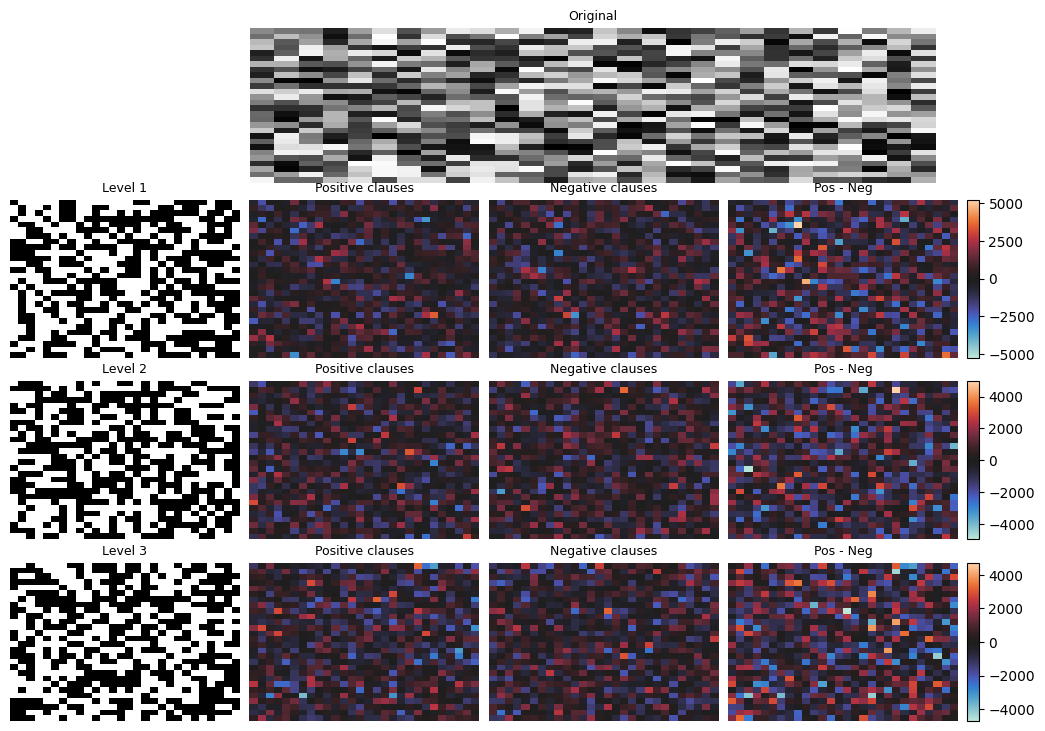

In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# dummy data
n_rows = 3
n_heatmap_cols = 3
n_cols = 1 + n_heatmap_cols + 1  # binary + heatmaps + colorbar
col_ratios = [1] + [1] * n_heatmap_cols + [0.05]
cmap = "icefire"

fig = plt.figure(figsize=(2.5 * n_cols, 2.5 * n_rows + 1.5))

outer = gridspec.GridSpec(
    2, n_cols,
    height_ratios=[0.89, n_rows],
    width_ratios=col_ratios,
    hspace=0.05
)

# ---- ORIGINAL IMAGE ----
ax_orig = fig.add_subplot(outer[0, 1:1 + n_heatmap_cols])
ax_orig.imshow(np.random.rand(28, 28), cmap="gray", aspect='auto')
ax_orig.set_title("Original", fontsize=9)
ax_orig.axis("off")
fig.add_subplot(outer[0, 0]).axis("off")
fig.add_subplot(outer[0, -1]).axis("off")

# ---- INNER GRID ----
inner = gridspec.GridSpecFromSubplotSpec(
    n_rows, n_cols,
    subplot_spec=outer[1, :],
    width_ratios=col_ratios,
    wspace=0.05,
    hspace=0.15
)

for row in range(n_rows):
    data_pos  = np.random.randn(28, 28) * 1000
    data_neg  = np.random.randn(28, 28) * 1000
    data_diff = data_pos - data_neg
    vmax = max(np.abs(data_pos).max(), np.abs(data_neg).max(), np.abs(data_diff).max())
    norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)

    # binary image
    ax_bin = fig.add_subplot(inner[row, 0])
    ax_bin.imshow(np.random.randint(0, 2, (28, 28)), cmap="gray", aspect='auto')
    ax_bin.set_title(f"Level {row + 1}", fontsize=9)
    ax_bin.axis("off")
    for spine in ax_bin.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('lightgray')
        spine.set_linewidth(0.8)

    # heatmaps
    for col_idx, (data, title) in enumerate([
        (data_pos,  "Positive clauses"),
        (data_neg,  "Negative clauses"),
        (data_diff, "Pos - Neg"),
    ]):
        ax = fig.add_subplot(inner[row, 1 + col_idx])
        sns.heatmap(
            data, ax=ax, cmap=cmap, center=0,
            vmin=-vmax, vmax=vmax, cbar=False,
            square=False, xticklabels=False, yticklabels=False
        )
        ax.set_title(title, fontsize=9)

    # colorbar
    ax_cb = fig.add_subplot(inner[row, -1])
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=ax_cb)

plt.show()